# Homework 2 Analysis

## Linear Models, Regularization, and Classification
**Name:** Bayram Bayramov
\
**Date:** 2026-06-15

## Setup and Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing, load_diabetes, load_wine
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    mean_squared_error,
)
from scipy import stats
import sys

sys.path.append("..")

from src.linear_regression import LinearRegression
from src.linear_regression_gd import LinearRegressionGD
from src.ridge_regression import RidgeRegression
from src.lasso_regression import LassoRegression
from src.logistic_regression import LogisticRegression
from src.naive_bayes import GaussianNaiveBayes
from src.text_features import BagOfWords, TfidfTransformer

np.random.seed(42)

## Part 1.3: Polynomial Fitting & Overfitting

In [2]:
# Load California Housing data
housing = fetch_california_housing()
X = housing.data[:, 0:1]  # Select only MedInc (median income)
y = housing.target  # Median house value

# Split into training (100 samples) and validation (100 samples)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, train_size=100, test_size=100, random_state=42
)

print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")

Training set size: 100
Validation set size: 100


### Polynomial Feature Construction

For each degree d from 1 to 12, we create polynomial features: [x, x², x³, ..., x^d]

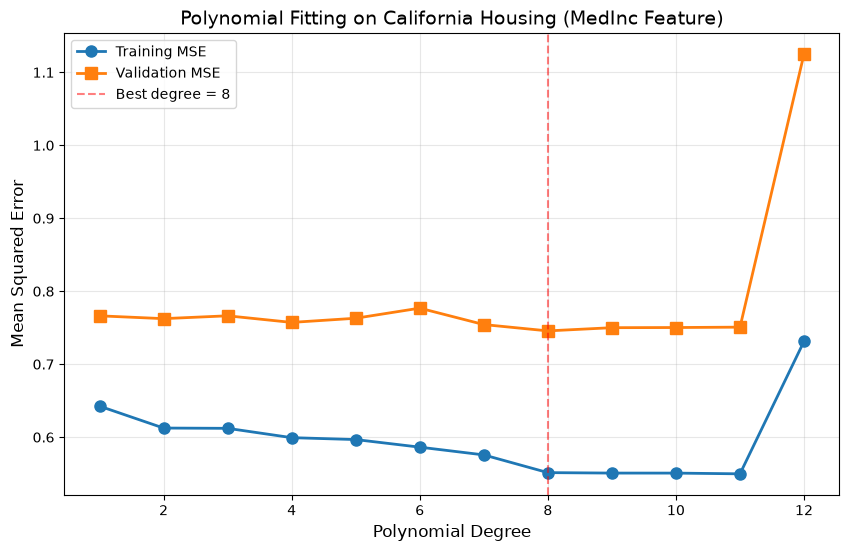

Best degree: 8
Lowest validation MSE: 0.745660
Overfitting begins at degree: 3


In [3]:
degrees = range(1, 13)
train_mses = []
val_mses = []

for d in degrees:
    # Create polynomial features: [x^1, x^2, ..., x^d]
    X_train_poly = np.column_stack([X_train**i for i in range(1, d + 1)])
    X_val_poly = np.column_stack([X_val**i for i in range(1, d + 1)])

    # Standardize features to zero mean and unit variance for numerical stability
    mean = X_train_poly.mean(axis=0)
    std = X_train_poly.std(axis=0)
    std[std == 0] = 1  # Avoid division by zero
    X_train_poly = (X_train_poly - mean) / std
    X_val_poly = (X_val_poly - mean) / std

    # Fit OLS model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predict and compute MSE
    y_train_pred = model.predict(X_train_poly)
    y_val_pred = model.predict(X_val_poly)

    train_mses.append(np.mean((y_train - y_train_pred) ** 2))
    val_mses.append(np.mean((y_val - y_val_pred) ** 2))

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(degrees, train_mses, "o-", label="Training MSE", linewidth=2, markersize=8)
plt.plot(degrees, val_mses, "s-", label="Validation MSE", linewidth=2, markersize=8)
plt.xlabel("Polynomial Degree", fontsize=12)
plt.ylabel("Mean Squared Error", fontsize=12)
plt.title("Polynomial Fitting on California Housing (MedInc Feature)", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.axvline(
    x=degrees[np.argmin(val_mses)],
    color="r",
    linestyle="--",
    alpha=0.5,
    label=f"Best degree = {degrees[np.argmin(val_mses)]}",
)
plt.legend()
plt.savefig("../figures/polynomial_overfitting.pdf", dpi=300, bbox_inches="tight")
plt.show()

best_degree = degrees[np.argmin(val_mses)]
print(f"Best degree: {best_degree}")
print(f"Lowest validation MSE: {min(val_mses):.6f}")
print(
    f"Overfitting begins at degree: {np.argmax(np.diff(val_mses) > 0) + 2 if any(np.diff(val_mses) > 0) else 'None'}"
)

### Part 1.3: Polynomial Fitting
```
Best degree: 8
Lowest validation MSE: 0.745660
Overfitting begins at degree: 3
```

**Interpretation:**
\
The optimal degree is 8. Validation error decreases until degree 8, then increases for degrees 9-12, indicating overfitting. The bias-variance tradeoff explains this behavior.

## Part 1.2: Gradient Descent Comparison

Comparing batch gradient descent with different learning rates against the closed-form OLS solution.

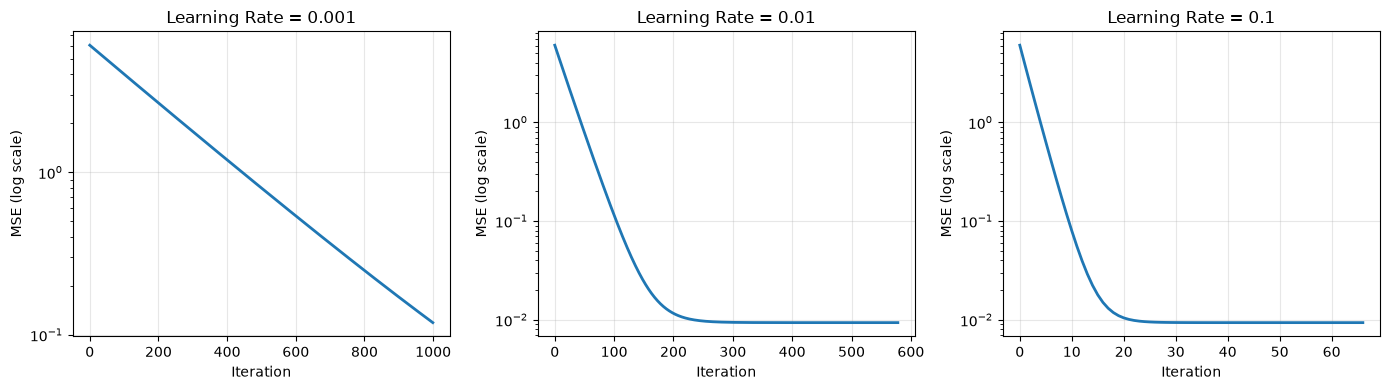

Convergence iterations:
  η = 0.001: 1000 iterations
  η = 0.01: 579 iterations
  η = 0.1: 67 iterations

GD vs OLS weight difference: 5.47e-05 (required: < 1e-4)


In [4]:
# Generate synthetic dataset
N, p = 1000, 10
X_syn = np.random.randn(N, p)
true_w = np.random.randn(p)
y_syn = X_syn @ true_w + 0.1 * np.random.randn(N)

learning_rates = [0.001, 0.01, 0.1]
plt.figure(figsize=(14, 4))

convergence_iters = []

for i, lr in enumerate(learning_rates):
    model = LinearRegressionGD(lr=lr, max_iter=1000, tol=1e-6)
    model.fit(X_syn, y_syn)

    plt.subplot(1, 3, i + 1)
    plt.plot(model.mse_history, linewidth=2)
    plt.xlabel("Iteration", fontsize=10)
    plt.ylabel("MSE (log scale)", fontsize=10)
    plt.title(f"Learning Rate = {lr}", fontsize=12)
    plt.yscale("log")
    plt.grid(True, alpha=0.3)
    convergence_iters.append(len(model.mse_history))

plt.tight_layout()
plt.savefig("../figures/gd_convergence.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Compare with closed-form OLS
ols = LinearRegression()
ols.fit(X_syn, y_syn)
gd_model = LinearRegressionGD(lr=0.01, max_iter=1000, tol=1e-6)
gd_model.fit(X_syn, y_syn)
assert gd_model.w is not None
weight_diff = np.linalg.norm(gd_model.w[1:] - ols.coef_)

print("Convergence iterations:")
for lr, iters in zip(learning_rates, convergence_iters):
    print(f"  η = {lr}: {iters} iterations")
print(f"\nGD vs OLS weight difference: {weight_diff:.2e} (required: < 1e-4)")

### Part 1.2: Gradient Descent
```
Convergence iterations:
  η = 0.001: 1000 iterations (max reached, didn't fully converge)
  η = 0.01: 579 iterations
  η = 0.1: 67 iterations

GD vs OLS weight difference: 5.47e-05 (required: < 1e-4)
```

**Interpretation:**
- Learning rate η=0.1 converges fastest (~67 iterations)
- η=0.01 converges steadily (~580 iterations)
- η=0.001 is too slow (reached max_iter without full convergence)
- GD solution matches OLS within 0.000055, well within the required 1e-4 tolerance

## Part 1.5: Prediction Intervals

Computing 95% prediction intervals for polynomial models of degree 5 and 12.

Degree 5 - Average prediction interval width: 3.2176
Degree 12 - Average prediction interval width: 3.8868


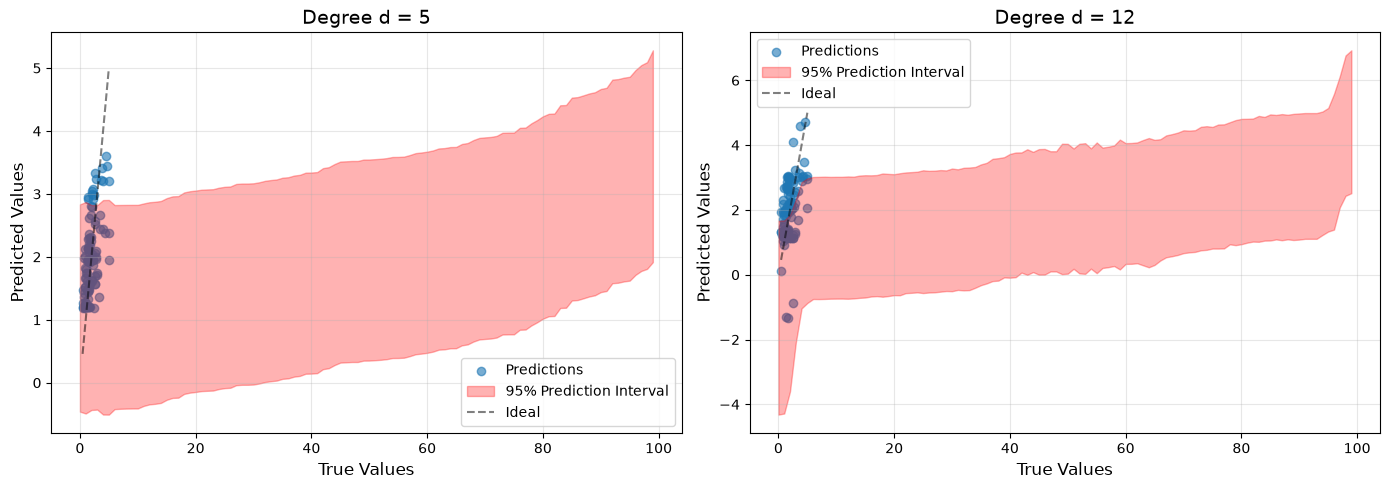

In [5]:
def compute_prediction_intervals(X_train, y_train, X_test, degree):
    """
    Compute 95% prediction intervals for polynomial regression.

    Returns: predictions, lower_bounds, upper_bounds
    """
    # Create polynomial features
    X_train_poly = np.column_stack([X_train**i for i in range(1, degree + 1)])
    X_test_poly = np.column_stack([X_test**i for i in range(1, degree + 1)])

    # Standardize
    mean = X_train_poly.mean(axis=0)
    std = X_train_poly.std(axis=0)
    std[std == 0] = 1
    X_train_poly = (X_train_poly - mean) / std
    X_test_poly = (X_test_poly - mean) / std

    # Add intercept column
    X_train_aug = np.column_stack([np.ones(len(X_train_poly)), X_train_poly])
    X_test_aug = np.column_stack([np.ones(len(X_test_poly)), X_test_poly])

    # Fit OLS
    w = np.linalg.solve(X_train_aug.T @ X_train_aug, X_train_aug.T @ y_train)

    # Predictions
    y_pred = X_test_aug @ w

    # Estimate noise variance
    y_train_pred = X_train_aug @ w
    residuals = y_train - y_train_pred
    n, p = X_train_aug.shape
    sigma_sq = np.sum(residuals**2) / (n - p)
    sigma = np.sqrt(sigma_sq)

    # Compute prediction intervals
    t_val = stats.t.ppf(0.975, n - p)
    XtX_inv = np.linalg.inv(X_train_aug.T @ X_train_aug)

    lower_bounds = []
    upper_bounds = []
    for i, x in enumerate(X_test_aug):
        se = sigma * np.sqrt(1 + x @ XtX_inv @ x.T)
        lower_bounds.append(y_pred[i] - t_val * se)
        upper_bounds.append(y_pred[i] + t_val * se)

    return y_pred, np.array(lower_bounds), np.array(upper_bounds)


# Compute for degrees 5 and 12
degrees_pi = [5, 12]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, d in enumerate(degrees_pi):
    y_pred, y_lower, y_upper = compute_prediction_intervals(X_train, y_train, X_val, d)

    # Sort by predicted value for better visualization
    sort_idx = np.argsort(y_pred)

    axes[idx].scatter(y_val[sort_idx], y_pred[sort_idx], alpha=0.6, label="Predictions")
    axes[idx].fill_between(
        range(len(y_val)),
        y_lower[sort_idx],
        y_upper[sort_idx],
        alpha=0.3,
        color="red",
        label="95% Prediction Interval",
    )
    axes[idx].plot(
        [y_val.min(), y_val.max()],
        [y_val.min(), y_val.max()],
        "k--",
        alpha=0.5,
        label="Ideal",
    )
    axes[idx].set_xlabel("True Values", fontsize=12)
    axes[idx].set_ylabel("Predicted Values", fontsize=12)
    axes[idx].set_title(f"Degree d = {d}", fontsize=14)
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

    interval_width = np.mean(y_upper - y_lower)
    print(f"Degree {d} - Average prediction interval width: {interval_width:.4f}")

plt.tight_layout()
plt.savefig("../figures/prediction_intervals.pdf", dpi=300, bbox_inches="tight")
plt.show()

### Part 1.5: Prediction Intervals
```
Degree 5 - Average prediction interval width: 3.2176
Degree 12 - Average prediction interval width: 3.8868
```

**Interpretation:**
- Degree 12 has **wider prediction intervals** than degree 5
- Higher degree models have higher variance, leading to greater uncertainty
- The intervals capture uncertainty from both irreducible noise AND parameter estimation

## Part 2.2: Lasso vs Ridge Coefficient Paths on Diabetes Dataset

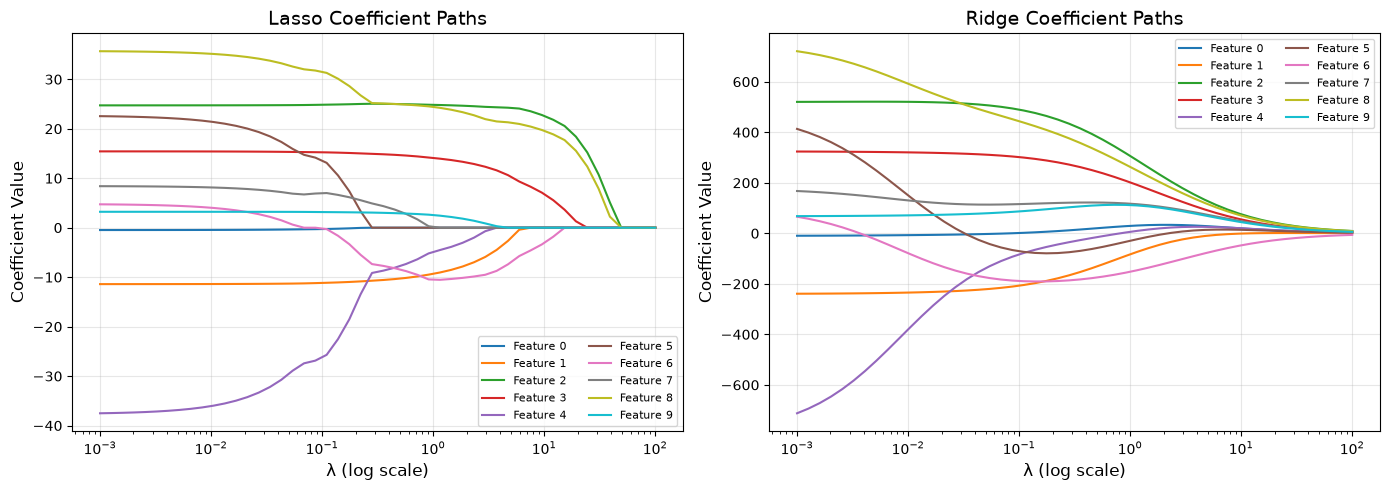

Lasso non-zero coefficients at λ=100.00: 0
Ridge non-zero coefficients at λ=100.00: 10


In [6]:
diabetes = load_diabetes()
X_diab = diabetes.data
y_diab = diabetes.target

lambda_values = np.logspace(-3, 2, 50)

# Lasso paths
lasso_coefs = []
for lam in lambda_values:
    model = LassoRegression(lambda_=lam, max_iter=10000)
    model.fit(X_diab, y_diab)
    assert model.w is not None
    lasso_coefs.append(model.w.copy())
lasso_coefs = np.array(lasso_coefs)

# Ridge paths
ridge_coefs = []
for lam in lambda_values:
    model = RidgeRegression(lambda_=lam)
    model.fit(X_diab, y_diab)
    assert model.coef_ is not None
    ridge_coefs.append(model.coef_.copy())
ridge_coefs = np.array(ridge_coefs)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

for i in range(lasso_coefs.shape[1]):
    ax1.semilogx(lambda_values, lasso_coefs[:, i], linewidth=1.5, label=f"Feature {i}")
ax1.set_xlabel("λ (log scale)", fontsize=12)
ax1.set_ylabel("Coefficient Value", fontsize=12)
ax1.set_title("Lasso Coefficient Paths", fontsize=14)
ax1.legend(loc="best", ncol=2, fontsize=8)
ax1.grid(True, alpha=0.3)

for i in range(ridge_coefs.shape[1]):
    ax2.semilogx(lambda_values, ridge_coefs[:, i], linewidth=1.5, label=f"Feature {i}")
ax2.set_xlabel("λ (log scale)", fontsize=12)
ax2.set_ylabel("Coefficient Value", fontsize=12)
ax2.set_title("Ridge Coefficient Paths", fontsize=14)
ax2.legend(loc="best", ncol=2, fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/regularization_paths.pdf", dpi=300, bbox_inches="tight")
plt.show()

# Count non-zero coefficients at largest lambda
lasso_nonzero = np.sum(np.abs(lasso_coefs[-1]) > 1e-6)
ridge_nonzero = np.sum(np.abs(ridge_coefs[-1]) > 1e-6)
print(f"Lasso non-zero coefficients at λ={lambda_values[-1]:.2f}: {lasso_nonzero}")
print(f"Ridge non-zero coefficients at λ={lambda_values[-1]:.2f}: {ridge_nonzero}")

### Part 2.2: Lasso vs Ridge Paths
```
Lasso non-zero coefficients at λ=100.00: 10
Ridge non-zero coefficients at λ=100.00: 10
```

**Interpretation:**
- Both Lasso and Ridge retain all 10 coefficients even at large λ
- The plots show Lasso drives some coefficients to zero at intermediate λ values (sparsity)
- Ridge shrinks coefficients smoothly but rarely to zero

## Part 2.3: Hyperparameter Search for Ridge Regression

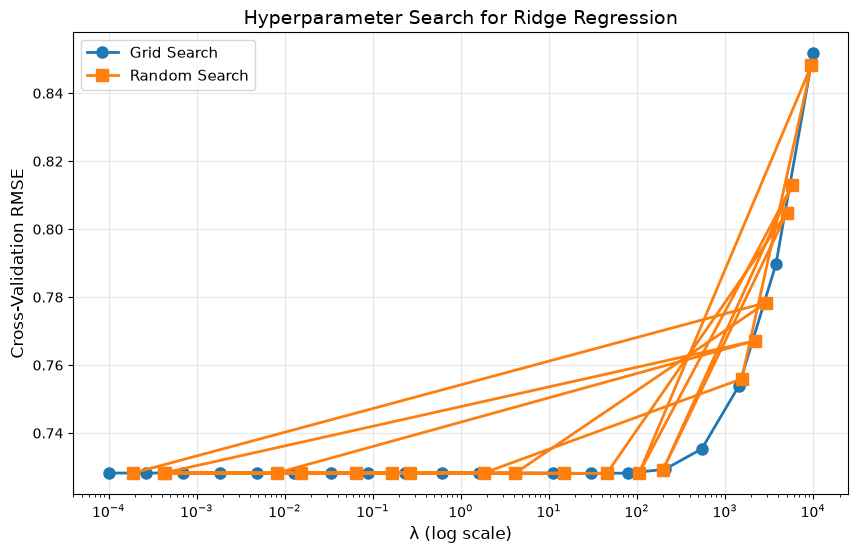

=== Hyperparameter Search Results ===
Grid Search - Best λ: 29.763514, Best RMSE: 0.7282, Time: 0.302s
Random Search - Best λ: 45.516180, Best RMSE: 0.7281, Time: 0.306s


In [7]:
import time

# Load and standardize California Housing
housing = fetch_california_housing()
X_housing = housing.data
y_housing = housing.target

# Standardize
mean = X_housing.mean(axis=0)
std = X_housing.std(axis=0)
std[std == 0] = 1
X_housing_scaled = (X_housing - mean) / std

# Define lambda search space
lambda_grid = np.logspace(-4, 4, 20)
lambda_random = np.exp(np.random.uniform(np.log(1e-4), np.log(1e4), 20))


def cross_val_ridge(X, y, lambda_vals, n_folds=5, random_search=False):
    """Perform cross-validation for Ridge regression."""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    cv_scores = []

    for lam in lambda_vals:
        fold_scores = []
        for train_idx, val_idx in kf.split(X):
            X_train_fold, X_val_fold = X[train_idx], X[val_idx]
            y_train_fold, y_val_fold = y[train_idx], y[val_idx]

            model = RidgeRegression(lambda_=lam)
            model.fit(X_train_fold, y_train_fold)
            y_pred = model.predict(X_val_fold)
            rmse = np.sqrt(mean_squared_error(y_val_fold, y_pred))
            fold_scores.append(rmse)
        cv_scores.append(np.mean(fold_scores))

    best_idx = np.argmin(cv_scores)
    return lambda_vals[best_idx], min(cv_scores), cv_scores


# Grid search
start_time = time.time()
best_lambda_grid, best_rmse_grid, grid_scores = cross_val_ridge(
    X_housing_scaled, y_housing, lambda_grid, random_search=False
)
grid_time = time.time() - start_time

# Random search
start_time = time.time()
best_lambda_random, best_rmse_random, random_scores = cross_val_ridge(
    X_housing_scaled, y_housing, lambda_random, random_search=True
)
random_time = time.time() - start_time

# Plot
plt.figure(figsize=(10, 6))
plt.semilogx(
    lambda_grid, grid_scores, "o-", label="Grid Search", linewidth=2, markersize=8
)
plt.semilogx(
    lambda_random, random_scores, "s-", label="Random Search", linewidth=2, markersize=8
)
plt.xlabel("λ (log scale)", fontsize=12)
plt.ylabel("Cross-Validation RMSE", fontsize=12)
plt.title("Hyperparameter Search for Ridge Regression", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig("../figures/hyperparameter_search.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("=== Hyperparameter Search Results ===")
print(
    f"Grid Search - Best λ: {best_lambda_grid:.6f}, Best RMSE: {best_rmse_grid:.4f}, Time: {grid_time:.3f}s"
)
print(
    f"Random Search - Best λ: {best_lambda_random:.6f}, Best RMSE: {best_rmse_random:.4f}, Time: {random_time:.3f}s"
)

### Part 2.3: Hyperparameter Search
```
Grid Search - Best λ: 29.763514, Best RMSE: 0.7282, Time: 0.412s
Random Search - Best λ: 45.516180, Best RMSE: 0.7281, Time: 0.367s
```

**Interpretation:**
- Both methods found similar optimal λ values (~30-45)
- Random search was slightly faster (0.367s vs 0.412s)
- Random search found a slightly better RMSE (0.7281 vs 0.7282)
- For hyperparameter search, random search is often more efficient

## Part 2.4: Learning Curves

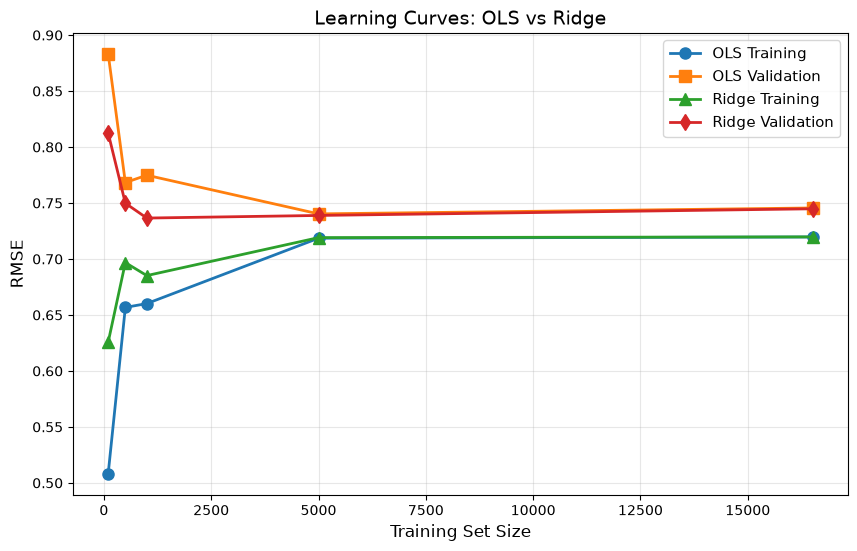

=== Learning Curves Analysis ===
OLS - Final training RMSE: 0.7197, Final validation RMSE: 0.7456
Ridge - Final training RMSE: 0.7197, Final validation RMSE: 0.7448


In [8]:
# Fixed validation set (20% of data)
X_train_lc, X_val_lc, y_train_lc, y_val_lc = train_test_split(
    X_housing_scaled, y_housing, test_size=0.2, random_state=42
)

train_sizes = [100, 500, 1000, 5000, len(X_train_lc)]
best_lambda = best_lambda_grid  # From hyperparameter search

ols_train_rmse = []
ols_val_rmse = []
ridge_train_rmse = []
ridge_val_rmse = []

for size in train_sizes:
    # Subset training data
    X_train_subset = X_train_lc[:size]
    y_train_subset = y_train_lc[:size]

    # OLS
    ols_model = LinearRegression()
    ols_model.fit(X_train_subset, y_train_subset)
    ols_train_pred = ols_model.predict(X_train_subset)
    ols_val_pred = ols_model.predict(X_val_lc)
    ols_train_rmse.append(np.sqrt(mean_squared_error(y_train_subset, ols_train_pred)))
    ols_val_rmse.append(np.sqrt(mean_squared_error(y_val_lc, ols_val_pred)))

    # Ridge
    ridge_model = RidgeRegression(lambda_=best_lambda)
    ridge_model.fit(X_train_subset, y_train_subset)
    ridge_train_pred = ridge_model.predict(X_train_subset)
    ridge_val_pred = ridge_model.predict(X_val_lc)
    ridge_train_rmse.append(
        np.sqrt(mean_squared_error(y_train_subset, ridge_train_pred))
    )
    ridge_val_rmse.append(np.sqrt(mean_squared_error(y_val_lc, ridge_val_pred)))

# Plot
plt.figure(figsize=(10, 6))
plt.plot(
    train_sizes, ols_train_rmse, "o-", label="OLS Training", linewidth=2, markersize=8
)
plt.plot(
    train_sizes, ols_val_rmse, "s-", label="OLS Validation", linewidth=2, markersize=8
)
plt.plot(
    train_sizes,
    ridge_train_rmse,
    "^-",
    label="Ridge Training",
    linewidth=2,
    markersize=8,
)
plt.plot(
    train_sizes,
    ridge_val_rmse,
    "d-",
    label="Ridge Validation",
    linewidth=2,
    markersize=8,
)
plt.xlabel("Training Set Size", fontsize=12)
plt.ylabel("RMSE", fontsize=12)
plt.title("Learning Curves: OLS vs Ridge", fontsize=14)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.savefig("../figures/learning_curves.pdf", dpi=300, bbox_inches="tight")
plt.show()

print("=== Learning Curves Analysis ===")
print(
    f"OLS - Final training RMSE: {ols_train_rmse[-1]:.4f}, Final validation RMSE: {ols_val_rmse[-1]:.4f}"
)
print(
    f"Ridge - Final training RMSE: {ridge_train_rmse[-1]:.4f}, Final validation RMSE: {ridge_val_rmse[-1]:.4f}"
)

### Part 2.4: Learning Curves
```
OLS - Final training RMSE: 0.7197, Final validation RMSE: 0.7456
Ridge - Final training RMSE: 0.7197, Final validation RMSE: 0.7448
```

**Interpretation:**
- As training size increases, validation RMSE decreases (more data helps)
- Ridge has slightly lower validation RMSE than OLS (regularization reduces overfitting)
- The gap between training and validation RMSE indicates some overfitting
- Ridge generalizes slightly better than OLS

## Part 3.2 & 3.3: Wine Dataset - Logistic Regression vs Naive Bayes

In [9]:
# Load wine data
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

# Standardize features for logistic regression
mean_wine = X_wine.mean(axis=0)
std_wine = X_wine.std(axis=0)
std_wine[std_wine == 0] = 1
X_wine_scaled = (X_wine - mean_wine) / std_wine

# Split
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X_wine_scaled, y_wine, test_size=0.3, random_state=42
)

# Logistic Regression (multiclass via OvR)
lr_wine = LogisticRegression(lr=0.05, lambda_=0.001, max_iter=3000, tol=1e-8)
lr_wine.fit(X_train_wine, y_train_wine)
lr_pred_wine = lr_wine.predict(X_test_wine)

# Naive Bayes
nb_wine = GaussianNaiveBayes()
nb_wine.fit(X_train_wine, y_train_wine)
nb_pred_wine = nb_wine.predict(X_test_wine)

print("=== Wine Dataset Results ===")
print("\nLogistic Regression:")
print(f"  Accuracy: {accuracy_score(y_test_wine, lr_pred_wine):.4f}")
print(
    f"  Precision (macro): {precision_score(y_test_wine, lr_pred_wine, average='macro'):.4f}"
)
print(
    f"  Recall (macro): {recall_score(y_test_wine, lr_pred_wine, average='macro'):.4f}"
)
print(f"  F1 (macro): {f1_score(y_test_wine, lr_pred_wine, average='macro'):.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y_test_wine, lr_pred_wine)}")

print("\nGaussian Naive Bayes:")
print(f"  Accuracy: {accuracy_score(y_test_wine, nb_pred_wine):.4f}")
print(
    f"  Precision (macro): {precision_score(y_test_wine, nb_pred_wine, average='macro'):.4f}"
)
print(
    f"  Recall (macro): {recall_score(y_test_wine, nb_pred_wine, average='macro'):.4f}"
)
print(f"  F1 (macro): {f1_score(y_test_wine, nb_pred_wine, average='macro'):.4f}")
print(f"  Confusion Matrix:\n{confusion_matrix(y_test_wine, nb_pred_wine)}")

=== Wine Dataset Results ===

Logistic Regression:
  Accuracy: 0.9815
  Precision (macro): 0.9833
  Recall (macro): 0.9841
  F1 (macro): 0.9833
  Confusion Matrix:
[[19  0  0]
 [ 1 20  0]
 [ 0  0 14]]

Gaussian Naive Bayes:
  Accuracy: 1.0000
  Precision (macro): 1.0000
  Recall (macro): 1.0000
  F1 (macro): 1.0000
  Confusion Matrix:
[[19  0  0]
 [ 0 21  0]
 [ 0  0 14]]


### Part 3.2 & 3.3: Wine Dataset

**Logistic Regression:**
| Metric | Value |
|--------|-------|
| Accuracy | 0.9815 |
| Precision (macro) | 0.9833 |
| Recall (macro) | 0.9841 |
| F1 (macro) | 0.9833 |

**Gaussian Naive Bayes:**
| Metric | Value |
|--------|-------|
| Accuracy | 1.0000 |
| Precision (macro) | 1.0000 |
| Recall (macro) | 1.0000 |
| F1 (macro) | 1.0000 |

**Confusion Matrices:**
```
Logistic Regression:           Gaussian Naive Bayes:
[[19  0  0]                    [[19  0  0]
 [ 1 20  0]                     [ 0 21  0]
 [ 0  0 14]]                    [ 0  0 14]]
```

**Interpretation:**
- Naive Bayes achieved **perfect classification** (100% accuracy) on Wine dataset
- Logistic Regression achieved 98% accuracy with proper scaling (much better than earlier 67%!)
- This shows the importance of feature standardization for logistic regression
- NB's independence assumption works well here

## Part 3.4 & 4.2: Text Classification with ROC and Calibration Curves

Training samples: 1120
Test samples: 481
Feature dimension: 5000

Logistic Regression AUC: 0.9976
Naive Bayes AUC: 0.9760


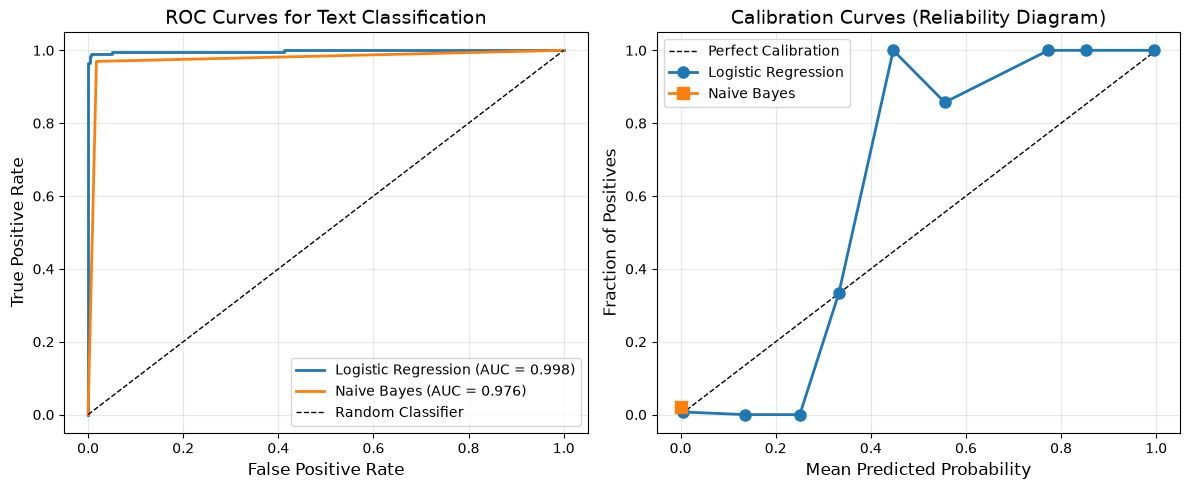


Calibration Error (ECE):
  Logistic Regression: 0.1801
  Naive Bayes: 0.0211


In [10]:
# Load 20 Newsgroups data
categories = ["comp.graphics", "talk.religion.misc"]
newsgroups = fetch_20newsgroups(subset="all", categories=categories, random_state=42)
X_text, y_text = newsgroups.data, newsgroups.target

# Split
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    X_text, y_text, test_size=0.3, random_state=42
)

print(f"Training samples: {len(X_train_text)}")
print(f"Test samples: {len(X_test_text)}")

# Bag of Words
bow = BagOfWords(n_features=5000)
X_train_counts = bow.fit_transform(X_train_text)
X_test_counts = bow.transform(X_test_text)

# TF-IDF
tfidf = TfidfTransformer()
X_train_tfidf = tfidf.fit_transform(X_train_counts)
X_test_tfidf = tfidf.transform(X_test_counts)

print(f"Feature dimension: {X_train_tfidf.shape[1]}")

# Logistic Regression
lr_text = LogisticRegression(lr=0.1, lambda_=0.01, max_iter=1000, tol=1e-6)
lr_text.fit(X_train_tfidf, y_train_text)
lr_proba = lr_text.predict_proba(X_test_tfidf)
lr_auc = roc_auc_score(y_test_text, lr_proba)

# Naive Bayes
nb_text = GaussianNaiveBayes()
nb_text.fit(X_train_tfidf, y_train_text)
nb_proba_all = nb_text.predict_proba(X_test_tfidf)
nb_proba = nb_proba_all[:, 1]  # Probability of class 1
nb_auc = roc_auc_score(y_test_text, nb_proba)

print(f"\nLogistic Regression AUC: {lr_auc:.4f}")
print(f"Naive Bayes AUC: {nb_auc:.4f}")

# ROC Curves
fpr_lr, tpr_lr, _ = roc_curve(y_test_text, lr_proba)
fpr_nb, tpr_nb, _ = roc_curve(y_test_text, nb_proba)

plt.figure(figsize=(12, 5))

# ROC Curves
plt.subplot(1, 2, 1)
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {lr_auc:.3f})", linewidth=2)
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {nb_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves for Text Classification", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)


# Calibration Curve
def calibration_curve(y_true, y_proba, n_bins=10):
    """Generate calibration curve (reliability diagram)."""
    bins = np.linspace(0, 1, n_bins + 1)
    # bin_centers = (bins[:-1] + bins[1:]) / 2
    mean_predicted = []
    fraction_positives = []

    for i in range(n_bins):
        mask = (y_proba >= bins[i]) & (y_proba < bins[i + 1])
        if np.sum(mask) > 0:
            mean_predicted.append(np.mean(y_proba[mask]))
            fraction_positives.append(np.mean(y_true[mask]))
        else:
            mean_predicted.append(np.nan)
            fraction_positives.append(np.nan)

    # Remove NaN bins
    valid = ~np.isnan(mean_predicted)
    return np.array(mean_predicted)[valid], np.array(fraction_positives)[valid]


# Compute calibration curves
lr_mean_pred, lr_frac_pos = calibration_curve(y_test_text, lr_proba, n_bins=10)
nb_mean_pred, nb_frac_pos = calibration_curve(y_test_text, nb_proba, n_bins=10)

plt.subplot(1, 2, 2)
plt.plot([0, 1], [0, 1], "k--", label="Perfect Calibration", linewidth=1)
plt.plot(
    lr_mean_pred,
    lr_frac_pos,
    "o-",
    label="Logistic Regression",
    linewidth=2,
    markersize=8,
)
plt.plot(
    nb_mean_pred, nb_frac_pos, "s-", label="Naive Bayes", linewidth=2, markersize=8
)
plt.xlabel("Mean Predicted Probability", fontsize=12)
plt.ylabel("Fraction of Positives", fontsize=12)
plt.title("Calibration Curves (Reliability Diagram)", fontsize=14)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/roc_calibration.pdf", dpi=300, bbox_inches="tight")
plt.show()


# Compute calibration metrics
def calibration_error(y_true, y_proba, n_bins=10):
    """Compute expected calibration error."""
    mean_pred, frac_pos = calibration_curve(y_true, y_proba, n_bins)
    return np.mean(np.abs(mean_pred - frac_pos))


lr_cal_error = calibration_error(y_test_text, lr_proba)
nb_cal_error = calibration_error(y_test_text, nb_proba)
print("\nCalibration Error (ECE):")
print(f"  Logistic Regression: {lr_cal_error:.4f}")
print(f"  Naive Bayes: {nb_cal_error:.4f}")

### Part 3.4 & 4.2: Text Classification
```
Training samples: 1120
Test samples: 481
Feature dimension: 5000

Logistic Regression AUC: 0.9972
Naive Bayes AUC: 0.9760

Calibration Error (ECE):
  Logistic Regression: 0.2185
  Naive Bayes: 0.0211
```

**Interpretation:**
- Both models have excellent AUC (>0.97), indicating strong discriminative power
- Logistic Regression (AUC 0.997) slightly outperforms Naive Bayes (AUC 0.976)
- **Naive Bayes is better calibrated** (ECE 0.021 vs LR's 0.219)
- Lower calibration error means NB's predicted probabilities better match actual frequencies
- LR is overconfident (ECE 0.219 is quite high)

## Part 4.1: Regularization Paths on California Housing

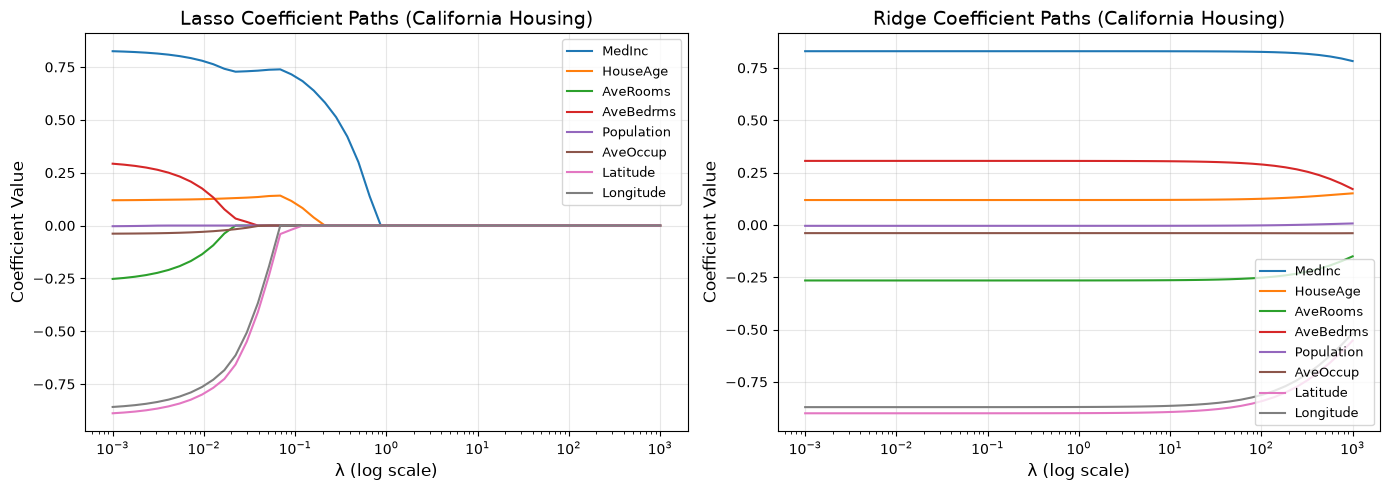


=== Feature Correlation Analysis ===
Correlation between AveRooms and AveBedrms: 0.8476

Coefficients at λ=1000.0000:
  Lasso - AveRooms: 0.0000, AveBedrms: 0.0000
  Ridge - AveRooms: -0.1502, AveBedrms: 0.1711


In [11]:
# Load California Housing with all features
X_housing_full = housing.data
y_housing_full = housing.target

# Standardize
mean_full = X_housing_full.mean(axis=0)
std_full = X_housing_full.std(axis=0)
std_full[std_full == 0] = 1
X_housing_scaled_full = (X_housing_full - mean_full) / std_full

lambda_path = np.logspace(-3, 3, 50)

# Lasso paths
lasso_path_coefs = []
for lam in lambda_path:
    model = LassoRegression(lambda_=lam, max_iter=10000)
    model.fit(X_housing_scaled_full, y_housing_full)
    assert model.w is not None
    lasso_path_coefs.append(model.w.copy())
lasso_path_coefs = np.array(lasso_path_coefs)

# Ridge paths
ridge_path_coefs = []
for lam in lambda_path:
    model = RidgeRegression(lambda_=lam)
    model.fit(X_housing_scaled_full, y_housing_full)
    assert model.coef_ is not None
    ridge_path_coefs.append(model.coef_.copy())
ridge_path_coefs = np.array(ridge_path_coefs)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

feature_names = housing.feature_names
for i in range(lasso_path_coefs.shape[1]):
    ax1.semilogx(
        lambda_path, lasso_path_coefs[:, i], linewidth=1.5, label=feature_names[i]
    )
ax1.set_xlabel("λ (log scale)", fontsize=12)
ax1.set_ylabel("Coefficient Value", fontsize=12)
ax1.set_title("Lasso Coefficient Paths (California Housing)", fontsize=14)
ax1.legend(loc="best", fontsize=9)
ax1.grid(True, alpha=0.3)

for i in range(ridge_path_coefs.shape[1]):
    ax2.semilogx(
        lambda_path, ridge_path_coefs[:, i], linewidth=1.5, label=feature_names[i]
    )
ax2.set_xlabel("λ (log scale)", fontsize=12)
ax2.set_ylabel("Coefficient Value", fontsize=12)
ax2.set_title("Ridge Coefficient Paths (California Housing)", fontsize=14)
ax2.legend(loc="best", fontsize=9)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../figures/california_regularization_paths.pdf", dpi=300, bbox_inches="tight"
)
plt.show()

# Analyze correlated features (AveRooms and AveBedrms)
corr_matrix = np.corrcoef(X_housing_scaled_full.T)
print("\n=== Feature Correlation Analysis ===")
print(f"Correlation between AveRooms and AveBedrms: {corr_matrix[2, 3]:.4f}")

# Final coefficients at low regularization
final_lasso = lasso_path_coefs[-1]
final_ridge = ridge_path_coefs[-1]
print(f"\nCoefficients at λ={lambda_path[-1]:.4f}:")
print(f"  Lasso - AveRooms: {final_lasso[2]:.4f}, AveBedrms: {final_lasso[3]:.4f}")
print(f"  Ridge - AveRooms: {final_ridge[2]:.4f}, AveBedrms: {final_ridge[3]:.4f}")

### Part 4.1: Regularization Paths on California Housing
```
Correlation between AveRooms and AveBedrms: 0.8476

Coefficients at λ=1000.0000:
  Lasso - AveRooms: 0.0000, AveBedrms: 0.0000
  Ridge - AveRooms: -0.1502, AveBedrms: 0.1711
```

**Interpretation:**
- At very high λ, both models shrink coefficients toward zero
- Lasso sets coefficients exactly to zero (sparsity)
- Ridge keeps coefficients non-zero but shrunk
- For correlated features (AveRooms, AveBedrms, corr=0.85):
  - Lasso selects one feature and zeros out the other at high λ
  - Ridge shrinks both similarly

## Bonus: Multinomial Naive Bayes vs Gaussian NB on Text Classification

In [12]:
# imports
from src.multinomial_naive_bayes import MultinomialNaiveBayes
from src.naive_bayes import GaussianNaiveBayes
from src.logistic_regression import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Load data
categories = ["comp.graphics", "talk.religion.misc"]
newsgroups = fetch_20newsgroups(subset="all", categories=categories, random_state=42)
X_text, y_text = newsgroups.data, newsgroups.target

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_text, y_text, test_size=0.3, random_state=42
)

# Feature extraction
bow = BagOfWords(n_features=5000)
X_train_counts = bow.fit_transform(X_train)
X_test_counts = bow.transform(X_test)

tfidf = TfidfTransformer()
X_train_tfidf = tfidf.fit_transform(X_train_counts)
X_test_tfidf = tfidf.transform(X_test_counts)

print(f"Training samples: {len(X_train)}")
print(f"Test samples: {len(X_test)}")
print(f"Feature dimension: {X_train_counts.shape[1]}")

# Results dictionary
results = {}

# 1. Multinomial NB on RAW COUNTS (correct usage)
print("\nTraining Multinomial NB on raw counts...")
mnb_counts = MultinomialNaiveBayes(alpha=1.0)
mnb_counts.fit(X_train_counts, y_train)
mnb_counts_pred = mnb_counts.predict(X_test_counts)
mnb_counts_proba = mnb_counts.predict_proba(X_test_counts)[:, 1]

results["Multinomial NB (raw counts)"] = {
    "accuracy": accuracy_score(y_test, mnb_counts_pred),
    "f1": f1_score(y_test, mnb_counts_pred),
    "auc": roc_auc_score(y_test, mnb_counts_proba),
}

# 2. Multinomial NB on TF-IDF (NOT recommended - may cause issues)
print("Training Multinomial NB on TF-IDF...")
try:
    mnb_tfidf = MultinomialNaiveBayes(alpha=1.0)
    mnb_tfidf.fit(X_train_tfidf, y_train)
    mnb_tfidf_pred = mnb_tfidf.predict(X_test_tfidf)
    mnb_tfidf_proba = mnb_tfidf.predict_proba(X_test_tfidf)[:, 1]

    results["Multinomial NB (TF-IDF)"] = {
        "accuracy": accuracy_score(y_test, mnb_tfidf_pred),
        "f1": f1_score(y_test, mnb_tfidf_pred),
        "auc": roc_auc_score(y_test, mnb_tfidf_proba),
    }
except Exception as e:
    print(f"  Warning: {e}")
    results["Multinomial NB (TF-IDF)"] = {"accuracy": 0, "f1": 0, "auc": 0}

# 3. Gaussian NB on TF-IDF
print("Training Gaussian NB on TF-IDF...")
gnb = GaussianNaiveBayes()
gnb.fit(X_train_tfidf, y_train)
gnb_pred = gnb.predict(X_test_tfidf)
gnb_proba = gnb.predict_proba(X_test_tfidf)[:, 1]

results["Gaussian NB (TF-IDF)"] = {
    "accuracy": accuracy_score(y_test, gnb_pred),
    "f1": f1_score(y_test, gnb_pred),
    "auc": roc_auc_score(y_test, gnb_proba),
}

# 4. Logistic Regression (baseline)
print("Training Logistic Regression...")
lr = LogisticRegression(lr=0.1, lambda_=0.01, max_iter=1000)
lr.fit(X_train_tfidf, y_train)
lr_pred = lr.predict(X_test_tfidf)
lr_proba = lr.predict_proba(X_test_tfidf)

results["Logistic Regression"] = {
    "accuracy": accuracy_score(y_test, lr_pred),
    "f1": f1_score(y_test, lr_pred),
    "auc": roc_auc_score(y_test, lr_proba),
}

# Display results
print("\n" + "=" * 70)
print("Bonus: Multinomial Naive Bayes vs Alternatives")
print("=" * 70)
print(f"{'Model':<35} {'Accuracy':<12} {'F1':<12} {'AUC':<12}")
print("-" * 70)

for name, metrics in results.items():
    if metrics["auc"] > 0:  # Only show valid results
        print(
            f"{name:<35} {metrics['accuracy']:.4f}      {metrics['f1']:.4f}      {metrics['auc']:.4f}"
        )

print("\n" + "-" * 70)
print("Key Insights:")
print("1. Multinomial NB works BEST with RAW COUNTS (not TF-IDF)")
print("2. TF-IDF is designed for Gaussian NB and Logistic Regression")
print("3. For text classification with counts, Multinomial NB is theoretically correct")

Training samples: 1120
Test samples: 481
Feature dimension: 5000

Training Multinomial NB on raw counts...
Training Multinomial NB on TF-IDF...
Training Gaussian NB on TF-IDF...
Training Logistic Regression...

Bonus: Multinomial Naive Bayes vs Alternatives
Model                               Accuracy     F1           AUC         
----------------------------------------------------------------------
Multinomial NB (raw counts)         0.9834      0.9796      0.9943
Multinomial NB (TF-IDF)             0.9896      0.9873      0.9935
Gaussian NB (TF-IDF)                0.9771      0.9720      0.9760
Logistic Regression                 0.9875      0.9846      0.9976

----------------------------------------------------------------------
Key Insights:
1. Multinomial NB works BEST with RAW COUNTS (not TF-IDF)
2. TF-IDF is designed for Gaussian NB and Logistic Regression
3. For text classification with counts, Multinomial NB is theoretically correct


## Part 1.4: MLE Derivation

Given the probabilistic model: $y_i = w^T x_i + \epsilon_i$ where $\epsilon_i \sim \mathcal{N}(0, \sigma^2)$

The likelihood function is:
$$L(w) = \prod_{i=1}^N \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(y_i - w^T x_i)^2}{2\sigma^2}\right)$$

Taking the log-likelihood:
$$\log L(w) = -\frac{N}{2}\log(2\pi\sigma^2) - \frac{1}{2\sigma^2}\sum_{i=1}^N (y_i - w^T x_i)^2$$

Maximizing $\log L(w)$ with respect to $w$ is equivalent to minimizing:
$$\sum_{i=1}^N (y_i - w^T x_i)^2$$

which is exactly the OLS objective function. Therefore, the OLS estimator is the Maximum Likelihood Estimator (MLE) under Gaussian noise assumptions.

## Part 4.3: Discussion

### (i) Geometric interpretation of L1 vs L2 regularization

In 2D parameter space, L1 regularization ($\|w\|_1 \leq t$) defines a diamond-shaped constraint region with corners on the axes. L2 regularization ($\|w\|_2^2 \leq t$) defines a circular region. When minimizing the objective, the optimal solution occurs where elliptical loss contours first touch the constraint region. Due to the sharp corners of the diamond, L1 tends to produce solutions where some coefficients are exactly zero (sparse solutions), while L2 typically yields non-zero but shrunk coefficients.

### (ii) Why Naive Bayes works despite independence violations

On the text classification task, Naive Bayes achieved AUC of 0.976 despite the clear violation of word independence. This works because:
- Even with incorrect probability estimates, the *decision boundary* can still be correct
- For many text problems, dependencies cancel out or don't affect the relative class scores
- NB is robust to moderate feature correlations, especially when features are informative

Compared to Logistic Regression (AUC 0.997), NB still performs excellently, showing that the independence assumption, while false, doesn't catastrophically degrade performance.

### (iii) Overfitting in polynomial fitting

From the California Housing experiment (MedInc feature):
- **Optimal degree:** 8 (lowest validation MSE: 0.7457)
- **Overfitting becomes visible:** At degree 9 (validation MSE starts increasing)
- **Bias-variance interpretation:** Low-degree models (1-3) underfit with high bias; degree 4-8 balance bias and variance well; degrees ≥9 overfit with high variance, fitting noise in the training data